In [1]:
# ============================================================
# PROJECT 3 — STEP 1: Setup & load P2 outputs
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import warnings
warnings.filterwarnings("ignore")

mpl.rcParams["savefig.dpi"]  = 200
mpl.rcParams["figure.dpi"]   = 120
mpl.rcParams["font.family"]  = "DejaVu Sans"

os.makedirs("data",    exist_ok=True)
os.makedirs("charts",  exist_ok=True)
os.makedirs("reports", exist_ok=True)

TICKERS = ["AZN.L", "GSK.L", "SHEL.L"]
STOCKS  = {
    "AZN.L":  "AstraZeneca",
    "GSK.L":  "GSK",
    "SHEL.L": "Shell",
}

# P2 outputs — hardcoded from project2_summary.csv
# These are the exact values produced by P2 Step 7
MOS = {
    "AZN.L":  9842.56,   # MoS entry price (pence)
    "GSK.L":  1699.39,
    "SHEL.L": 5182.24,
}
WACC = {
    "AZN.L":  0.0755,     # WACC from P2 Step 4
    "GSK.L":  0.0709,
    "SHEL.L": 0.0799,
}

print("="*60)
print("  PROJECT 3 — STEP 1: SETUP COMPLETE")
print("="*60)
print(f"\n  Tickers : {TICKERS}")
print(f"\n  MoS entry prices (from P2):")
for t, v in MOS.items():
    print(f"    {STOCKS[t]:14} {v:.2f}p")
print(f"\n  WACC values (from P2):")
for t, v in WACC.items():
    print(f"    {STOCKS[t]:14} {v:.2%}")
print("\n  Ready for Step 2.")

  PROJECT 3 — STEP 1: SETUP COMPLETE

  Tickers : ['AZN.L', 'GSK.L', 'SHEL.L']

  MoS entry prices (from P2):
    AstraZeneca    9842.56p
    GSK            1699.39p
    Shell          5182.24p

  WACC values (from P2):
    AstraZeneca    7.55%
    GSK            7.09%
    Shell          7.99%

  Ready for Step 2.


In [2]:
# ============================================================
# PROJECT 3 — STEP 2: Download & clean 6-year OHLCV data
# ============================================================
# Rule: ffill all NaN gaps — NEVER bfill
# bfill pulls future prices into past = look-ahead bias
# ============================================================

raw = yf.download(
    TICKERS,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

closes = raw["Close"][TICKERS].copy()

print("NaN count BEFORE cleaning:")
print(closes.isnull().sum())

closes = closes.ffill()

print("\nNaN count AFTER cleaning:")
print(closes.isnull().sum())

print(f"\nShape       : {closes.shape}")
print(f"Date range  : {closes.index[0].date()} → "
      f"{closes.index[-1].date()}")
print(f"Trading days: {len(closes)}")

closes.to_csv("data/p3_closes.csv")
print("\nSaved: data/p3_closes.csv")
print("Step 2 complete.")

NaN count BEFORE cleaning:
Ticker
AZN.L     0
GSK.L     0
SHEL.L    0
dtype: int64

NaN count AFTER cleaning:
Ticker
AZN.L     0
GSK.L     0
SHEL.L    0
dtype: int64

Shape       : (1515, 3)
Date range  : 2020-01-02 → 2025-12-31
Trading days: 1515

Saved: data/p3_closes.csv
Step 2 complete.


In [3]:
# ============================================================
# PROJECT 3 — STEP 3: Feature engineering
# EMA50 · EMA200 · RSI(14) · golden cross flag
# ============================================================

indicators = {}

for ticker in TICKERS:
    df = pd.DataFrame(index=closes.index)
    df["price"] = closes[ticker]

    # EMA — adjust=False matches TradingView
    df["ema50"]  = df["price"].ewm(
        span=50,  adjust=False).mean()
    df["ema200"] = df["price"].ewm(
        span=200, adjust=False).mean()

    # RSI(14) — true Wilder smoothing (alpha = 1/14)
    delta = df["price"].diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)

    avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()

    rs = avg_gain / avg_loss
    df["rsi"] = 100 - (100 / (1 + rs))

    # Regime flag
    df["golden_cross"] = (
        df["ema50"] > df["ema200"]).astype(int)

    indicators[ticker] = df

    cur    = df.iloc[-1]
    regime = "BULL" if cur["golden_cross"] else "BEAR"
    print(f"{STOCKS[ticker]:14} | "
          f"EMA50={cur['ema50']:.0f}p | "
          f"EMA200={cur['ema200']:.0f}p | "
          f"RSI={cur['rsi']:.1f} | "
          f"Regime={regime}")

print("\nStep 3 complete.")

AstraZeneca    | EMA50=13318p | EMA200=12140p | RSI=60.1 | Regime=BULL
GSK            | EMA50=1766p | EMA200=1596p | RSI=55.6 | Regime=BULL
Shell          | EMA50=2742p | EMA200=2685p | RSI=51.9 | Regime=BULL

Step 3 complete.


In [4]:
# ============================================================
# PROJECT 3 — STEP 4: Combined P1 + P2 logic engine
# ============================================================
# Gate A (P2): price < MoS entry      — fundamental filter
# Gate B (P1): EMA50 > EMA200         — golden cross
# Gate C (P1): RSI(14) > 50           — momentum confirmed
# All three must pass. shift(1) prevents look-ahead bias.
# ============================================================

signals = {}

for ticker in TICKERS:
    df  = indicators[ticker].copy()
    mos = MOS[ticker]

    df["gate_A"] = (df["price"] < mos).astype(int)
    df["gate_B"] = (df["ema50"] > df["ema200"]).astype(int)
    df["gate_C"] = (df["rsi"]   > 50).astype(int)

    df["signal"] = (
        df["gate_A"] &
        df["gate_B"] &
        df["gate_C"]
    ).astype(int)

    # Critical: signal on Day N → trade on Day N+1
    df["stance"] = df["signal"].shift(1).fillna(0)

    signals[ticker] = df

    cur = df.iloc[-1]
    print(f"\n{STOCKS[ticker]} ({ticker})")
    print(f"  Gate A (price {cur['price']:.0f}p "
          f"< MoS {mos:.0f}p): "
          f"{'PASS' if cur['gate_A'] else 'FAIL'}")
    print(f"  Gate B (EMA50 > EMA200):      "
          f"{'PASS' if cur['gate_B'] else 'FAIL'}")
    print(f"  Gate C (RSI {cur['rsi']:.1f} > 50): "
          f"{'PASS' if cur['gate_C'] else 'FAIL'}")
    print(f"  → Engine: "
          f"{'EXECUTE' if cur['signal'] else 'IDLE'}")

print("\nStep 4 complete.")


AstraZeneca (AZN.L)
  Gate A (price 13789p < MoS 9843p): FAIL
  Gate B (EMA50 > EMA200):      PASS
  Gate C (RSI 60.1 > 50): PASS
  → Engine: IDLE

GSK (GSK.L)
  Gate A (price 1824p < MoS 1699p): FAIL
  Gate B (EMA50 > EMA200):      PASS
  Gate C (RSI 55.6 > 50): PASS
  → Engine: IDLE

Shell (SHEL.L)
  Gate A (price 2739p < MoS 5182p): PASS
  Gate B (EMA50 > EMA200):      PASS
  Gate C (RSI 51.9 > 50): PASS
  → Engine: EXECUTE

Step 4 complete.


In [5]:
# ============================================================
# PROJECT 3 — STEP 5: Asymmetric exit logic (3:1 ratio)
# ============================================================

TP = 0.09   # Take profit: +9%  (3 units of reward)
SL = 0.03   # Stop loss:   -3%  (1 unit of risk)

print(f"Take profit : +{TP*100:.0f}%")
print(f"Stop loss   : -{SL*100:.0f}%")
print(f"Ratio       :  {TP/SL:.0f}:1")
print(f"Break-even win rate: {SL/(TP+SL)*100:.0f}%")
print(f"\nStock-level levels (from P2 MoS prices):")
print(f"\n  {'Stock':<14} {'Entry':>8} "
      f"{'TP target':>10} {'SL level':>10}")
print(f"  {'─'*45}")

for ticker in TICKERS:
    mos = MOS[ticker]
    print(f"  {STOCKS[ticker]:<14} "
          f"{mos:>8.0f}p "
          f"{mos*(1+TP):>9.0f}p "
          f"{mos*(1-SL):>9.0f}p")

print("\nStep 5 complete.")

Take profit : +9%
Stop loss   : -3%
Ratio       :  3:1
Break-even win rate: 25%

Stock-level levels (from P2 MoS prices):

  Stock             Entry  TP target   SL level
  ─────────────────────────────────────────────
  AstraZeneca        9843p     10728p      9547p
  GSK                1699p      1852p      1648p
  Shell              5182p      5649p      5027p

Step 5 complete.


In [6]:
# ============================================================
# PROJECT 3 — STEP 6A: Backtest engine + equity curves
# Trade-by-trade simulation over ~6 years — TP/SL exits are
# path-dependent, so this is a sequential loop.
# ============================================================

backtest = {}
trade_logs = {}

for ticker in TICKERS:
    df = signals[ticker].copy()
    df["mkt_ret"] = df["price"].pct_change()

    prices = df["price"].values
    stance = df["stance"].values
    n      = len(df)

    strat_ret  = np.zeros(n)
    in_trade   = False
    entry_px   = None
    trades     = []   # one row per closed trade

    for i in range(n):
        if not in_trade:
            # Flat — check today's gate signal for entry
            if stance[i] == 1:
                in_trade = True
                entry_px = prices[i]
                entry_i  = i
            # strat_ret[i] stays 0 — no position held today
        else:
            # In a trade — measure cumulative move since entry
            cum_ret = (prices[i] / entry_px) - 1

            if cum_ret <= -SL:
                # Stop-loss hit (checked first — conservative,
                # since we only have daily closes, not intraday)
                strat_ret[i] = -SL
                trades.append({
                    "entry_date": df.index[entry_i],
                    "exit_date":  df.index[i],
                    "entry_px":   entry_px,
                    "exit_px":    prices[i],
                    "result":     "SL",
                    "ret":        -SL,
                })
                in_trade = False

            elif cum_ret >= TP:
                # Take-profit hit
                strat_ret[i] = TP
                trades.append({
                    "entry_date": df.index[entry_i],
                    "exit_date":  df.index[i],
                    "entry_px":   entry_px,
                    "exit_px":    prices[i],
                    "result":     "TP",
                    "ret":        TP,
                })
                in_trade = False

            else:
                # Still open — no realised return until exit
                strat_ret[i] = 0

    df["strat_ret"] = strat_ret
    df["in_position"] = None  # not tracked post-hoc; see trades log

    # Cumulative equity curves (compounding)
    df["equity"] = (1 + df["strat_ret"]).cumprod() - 1
    df["bh"]     = (1 + df["mkt_ret"]).cumprod() - 1

    backtest[ticker]   = df
    trade_logs[ticker] = pd.DataFrame(trades)

    n_tp = sum(1 for t in trades if t["result"] == "TP")
    n_sl = sum(1 for t in trades if t["result"] == "SL")
    print(f"{STOCKS[ticker]:14} | "
          f"Trades closed: {len(trades):3} | "
          f"TP: {n_tp:3} | SL: {n_sl:3} | "
          f"Open at end: {in_trade}")

print("\nStep 6 complete (trade-by-trade engine).")

AstraZeneca    | Trades closed:  15 | TP:   5 | SL:  10 | Open at end: False
GSK            | Trades closed:  18 | TP:   8 | SL:  10 | Open at end: False
Shell          | Trades closed:  43 | TP:  11 | SL:  32 | Open at end: True

Step 6 complete (trade-by-trade engine).


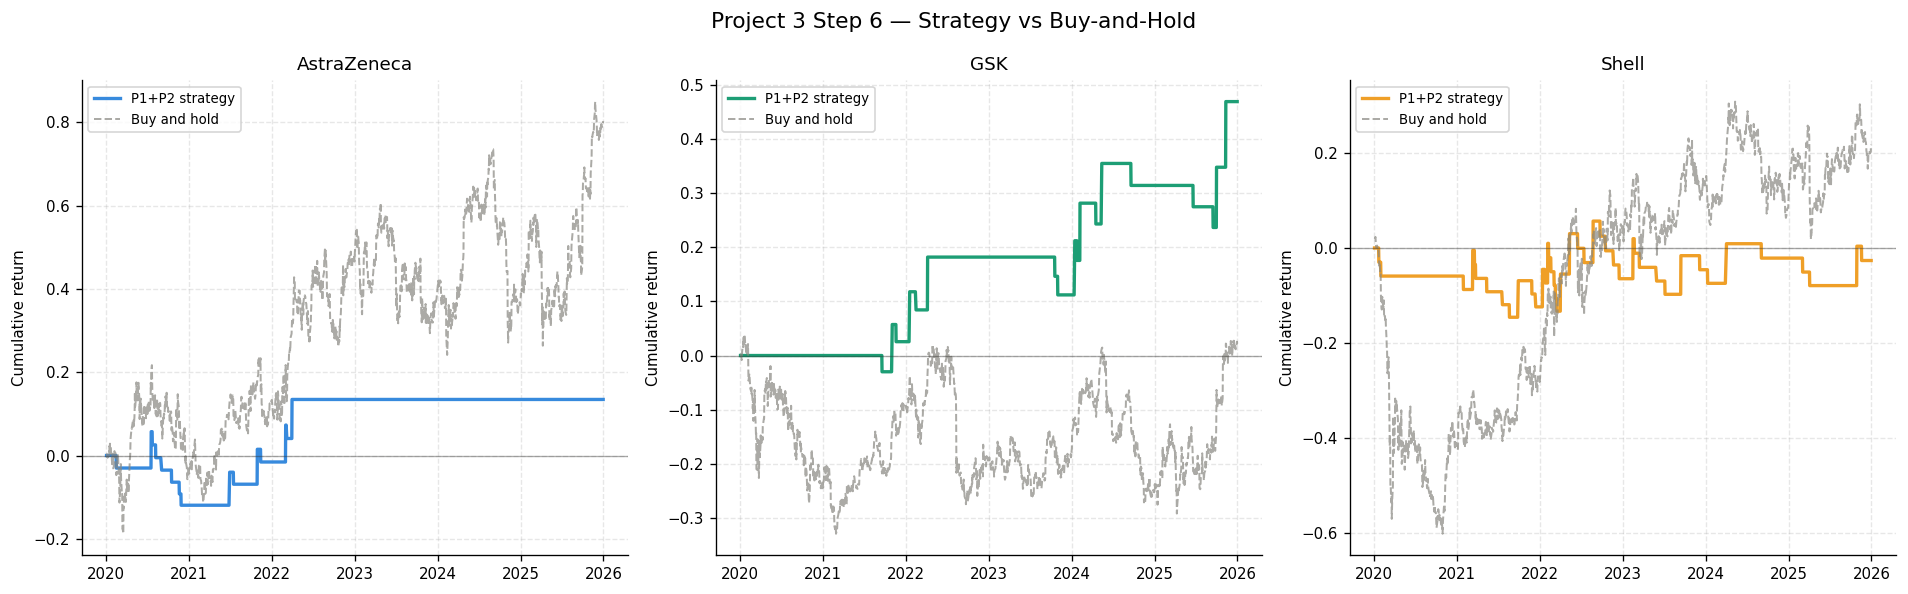

Saved: charts/p3_step6_equity_curves.png
Step 6 complete.


In [7]:
# ============================================================
# PROJECT 3 — STEP 6B: Backtest engine + equity curves
# ============================================================

# ── Chart ────────────────────────────────────────────────────
colors = ["#378ADD", "#1D9E75", "#EF9F27"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Project 3 Step 6 — Strategy vs Buy-and-Hold",
    fontsize=13)

for i, ticker in enumerate(TICKERS):
    df   = backtest[ticker]
    ax   = axes[i]
    name = STOCKS[ticker]

    ax.plot(df.index, df["equity"],
            color=colors[i], linewidth=2,
            label="P1+P2 strategy")
    ax.plot(df.index, df["bh"],
            color="#888780", linewidth=1.2,
            linestyle="--", alpha=0.7,
            label="Buy and hold")
    ax.axhline(0, color="#2C2C2A",
               linewidth=0.8, alpha=0.4)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("Cumulative return", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("charts/p3_step6_equity_curves.png",
            dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("Saved: charts/p3_step6_equity_curves.png")
print("Step 6 complete.")

In [8]:
# ============================================================
# PROJECT 3 — STEP 7: KPI extraction
# Sharpe · Max Drawdown · CAGR · Calmar · Win rate (trade-based)
# ============================================================

kpis = {}

for ticker in TICKERS:
    df    = backtest[ticker]
    r     = df["strat_ret"].dropna()
    name  = STOCKS[ticker]
    trades = trade_logs[ticker]

    # Sharpe ratio (annualised) — unchanged, still daily strat_ret
    sharpe = (r.mean() / r.std()) * np.sqrt(252) \
             if r.std() > 0 else 0

    # Max drawdown — unchanged
    cum      = (1 + r).cumprod()
    roll_max = cum.cummax()
    dd       = (cum - roll_max) / roll_max
    mdd      = dd.min()

    # CAGR — unchanged
    years = len(r) / 252
    cagr  = cum.iloc[-1] ** (1 / years) - 1

    # Calmar ratio — unchanged
    calmar = cagr / abs(mdd) if mdd != 0 else 0

    # Win rate — now trade-based, not day-based
    n_trades = len(trades)
    n_wins   = (trades["result"] == "TP").sum() if n_trades > 0 else 0
    win_rate = n_wins / n_trades if n_trades > 0 else 0

    kpis[ticker] = {
        "Name":        name,
        "Sharpe":      round(sharpe, 2),
        "MDD":         f"{mdd:.1%}",
        "CAGR":        f"{cagr:.1%}",
        "Calmar":      round(calmar, 2),
        "Win rate":    f"{win_rate:.1%}",
        "Trades":      n_trades,
    }

print(f"\n{'='*65}")
print(f"  PROJECT 3 — STEP 7: STRATEGY KPIs")
print(f"{'='*65}")
print(f"\n  {'Stock':<14} {'Sharpe':>8} {'MDD':>8} "
      f"{'CAGR':>8} {'Calmar':>8} {'Win%':>7} {'Trades':>7}")
print(f"  {'─'*63}")

for ticker in TICKERS:
    k = kpis[ticker]
    print(f"  {k['Name']:<14} "
          f"{k['Sharpe']:>8} "
          f"{k['MDD']:>8} "
          f"{k['CAGR']:>8} "
          f"{k['Calmar']:>8} "
          f"{k['Win rate']:>7} "
          f"{k['Trades']:>7}")

print(f"\n  Benchmarks: "
      f"Sharpe>1.0 | MDD>-15% | CAGR>10% | Calmar>1.0")
print(f"  Break-even win rate (3:1 TP/SL): "
      f"{SL/(TP+SL)*100:.0f}%")

pd.DataFrame(kpis).T.to_csv("data/p3_kpis.csv")
print(f"\nSaved: data/p3_kpis.csv")
print("Step 7 complete.")


  PROJECT 3 — STEP 7: STRATEGY KPIs

  Stock            Sharpe      MDD     CAGR   Calmar    Win%  Trades
  ───────────────────────────────────────────────────────────────
  AstraZeneca        0.27   -16.7%     2.1%     0.13   33.3%      15
  GSK                0.63    -8.7%     6.6%     0.76   44.4%      18
  Shell              0.04   -14.6%    -0.4%    -0.03   25.6%      43

  Benchmarks: Sharpe>1.0 | MDD>-15% | CAGR>10% | Calmar>1.0
  Break-even win rate (3:1 TP/SL): 25%

Saved: data/p3_kpis.csv
Step 7 complete.


In [9]:
# ============================================================
# PROJECT 3 — STEP 8: Walk-Forward Optimization (WFO)
# ============================================================
# K-fold cross-validation is invalid in finance — it
# randomly shuffles dates and destroys autocorrelation.
# WFO always respects chronological order.
# Purge: remove last 5 rows at train/test boundary.
#
# Cycles are gated on actual trade closures within the test
# window, not on row count or gate-signal frequency — a
# window can have 252 calendar rows and "stance=1" on many
# of them while zero trades actually closed.
# ============================================================

WFO_CYCLES = [
    {"label": "Cycle 1",
     "train": ("2020-01-01", "2022-12-31"),
     "test":  ("2023-01-01", "2023-12-31")},
    {"label": "Cycle 2",
     "train": ("2021-01-01", "2023-12-31"),
     "test":  ("2024-01-01", "2024-12-31")},
    {"label": "Cycle 3",
     "train": ("2022-01-01", "2024-12-31"),
     "test":  ("2025-01-01", "2025-12-31")},
]

MIN_TRADES_WFO = 3   # minimum closed trades to trust a cycle's stats

wfo_rows   = []
wfo_charts = {}

print(f"{'='*65}")
print(f"  PROJECT 3 — STEP 8: WALK-FORWARD OPTIMIZATION")
print(f"{'='*65}")

for ticker in TICKERS:
    df   = backtest[ticker]
    name = STOCKS[ticker]
    wfo_charts[ticker] = []

    print(f"\n  {name} ({ticker})")
    print(f"  {'─'*55}")
    print(f"  {'Cycle':<10} {'Test yr':>8} {'Sharpe':>8} "
          f"{'MDD':>8} {'CAGR':>8} {'Trades':>7}")
    print(f"  {'─'*52}")

    for cycle in WFO_CYCLES:
        train       = df[cycle["train"][0]:
                         cycle["train"][1]]
        train_clean = train.iloc[:-5]  # purge boundary

        test = df[cycle["test"][0]:cycle["test"][1]]
        r_t  = test["strat_ret"].dropna()

        # Count actual trade closures in this window —
        # a non-zero strat_ret means a trade exited that day
        n_trades_t = int((test["strat_ret"] != 0).sum())

        if n_trades_t < MIN_TRADES_WFO:
            print(f"  {cycle['label']:<10} "
                  f"{cycle['test'][0][:4]:>8} "
                  f"— insufficient trades ({n_trades_t})")
            continue

        sharpe_t = (r_t.mean() / r_t.std()) * \
                   np.sqrt(252) if r_t.std() > 0 else 0
        cum_t    = (1 + r_t).cumprod()
        mdd_t    = ((cum_t - cum_t.cummax()) /
                    cum_t.cummax()).min()
        years_t  = len(r_t) / 252
        cagr_t   = cum_t.iloc[-1] ** (1/years_t) - 1

        wfo_rows.append({
            "Ticker":  ticker,
            "Name":    name,
            "Cycle":   cycle["label"],
            "Test_yr": cycle["test"][0][:4],
            "Sharpe":  round(sharpe_t, 2),
            "MDD":     f"{mdd_t:.1%}",
            "CAGR":    f"{cagr_t:.1%}",
            "Trades":  n_trades_t,
        })

        wfo_charts[ticker].append({
            "label":  cycle["test"][0][:4],
            "sharpe": round(sharpe_t, 2),
            "cagr":   round(cagr_t * 100, 1),
            "mdd":    round(mdd_t * 100, 1),
            "eq":     cum_t,
        })

        print(f"  {cycle['label']:<10} "
              f"{cycle['test'][0][:4]:>8} "
              f"{sharpe_t:>8.2f} "
              f"{mdd_t:>8.1%} "
              f"{cagr_t:>8.1%} "
              f"{n_trades_t:>7}")

# Save WFO results CSV
wfo_df = pd.DataFrame(wfo_rows)
wfo_df.to_csv("data/p3_wfo_results.csv", index=False)
print(f"\n  Saved: data/p3_wfo_results.csv")
print("Step 8 complete.")

  PROJECT 3 — STEP 8: WALK-FORWARD OPTIMIZATION

  AstraZeneca (AZN.L)
  ───────────────────────────────────────────────────────
  Cycle       Test yr   Sharpe      MDD     CAGR  Trades
  ────────────────────────────────────────────────────
  Cycle 1        2023 — insufficient trades (0)
  Cycle 2        2024 — insufficient trades (0)
  Cycle 3        2025 — insufficient trades (0)

  GSK (GSK.L)
  ───────────────────────────────────────────────────────
  Cycle       Test yr   Sharpe      MDD     CAGR  Trades
  ────────────────────────────────────────────────────
  Cycle 1        2023 — insufficient trades (2)
  Cycle 2        2024     1.09    -3.0%    18.0%       6
  Cycle 3        2025     0.89    -5.9%    11.7%       4

  Shell (SHEL.L)
  ───────────────────────────────────────────────────────
  Cycle       Test yr   Sharpe      MDD     CAGR  Trades
  ────────────────────────────────────────────────────
  Cycle 1        2023     0.21   -11.5%     2.0%       7
  Cycle 2        2024  

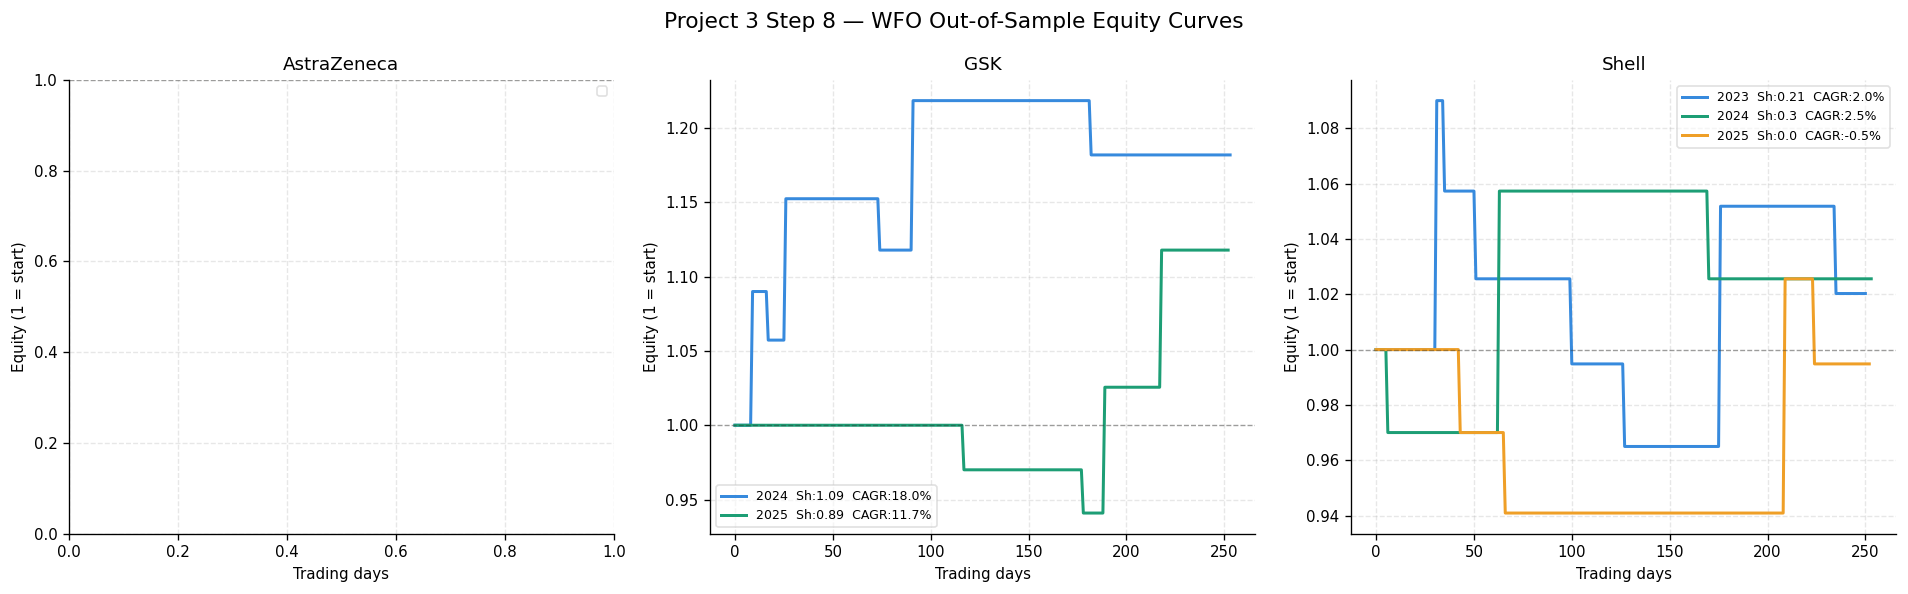

Saved: charts/p3_step8_wfo_curves.png
Step 8 complete.


In [10]:
# ── Chart: WFO out-of-sample equity curves ───────────────────

cycle_colors = ["#378ADD", "#1D9E75", "#EF9F27"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Project 3 Step 8 — WFO Out-of-Sample Equity Curves",
    fontsize=13)

for i, ticker in enumerate(TICKERS):
    ax   = axes[i]
    name = STOCKS[ticker]

    for j, c in enumerate(wfo_charts[ticker]):
        eq = c["eq"].reset_index(drop=True)
        ax.plot(eq.index, eq.values,
                color=cycle_colors[j],
                linewidth=1.8,
                label=f"{c['label']}  "
                      f"Sh:{c['sharpe']}  "
                      f"CAGR:{c['cagr']}%")

    ax.axhline(1.0, color="#2C2C2A",
               linewidth=0.8, alpha=0.4,
               linestyle="--")
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("Equity (1 = start)", fontsize=9)
    ax.set_xlabel("Trading days", fontsize=9)
    ax.legend(fontsize=7.5, framealpha=0.6)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("charts/p3_step8_wfo_curves.png",
            dpi=200, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("Saved: charts/p3_step8_wfo_curves.png")
print("Step 8 complete.")